## Zero-Shot Scoring

### Imports

In [6]:
import pandas as pd
from transformers import pipeline
import textwrap
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
#from transformers_interpret import ZeroShotClassificationExplainer
#import shap
#from IPython.display import display, HTML
import numpy as np

### Setup

In [2]:
df = pd.read_csv("all_papers.csv")

print(f"Amount of Papers: {df.shape[0]}")
print(df.head())

Amount of Papers: 174
                                               Title  \
0  Phantom Formations: Aesthetic Ideology and the...   
1  Immunocytochemical localization of AMPA recept...   
2  Ethnomusicology and Empiricism in the Twenty-F...   
3  Rapid SNP Discovery and Genetic Mapping Using ...   
4  Physiological correlates and emotional specifi...   

                                             Authors  Year  Journal  \
0                                    ['M. Redfield']  1996      160   
1                         ['Wendy Gaza', 'C. Ribak']  1997       17   
2                                      ['J. Becker']  2009       26   
3  ['N. Baird', 'Paul D. Etter', 'T. S. Atwood', ...  2008     3361   
4                     ['M. Benedek', 'C. Kaernbach']  2011      169   

                                            Abstract Extraction Method  
0  Redfield, Marc. Phantom Formations. Aesthetic ...        Method 1.1  
1  Immunocytochemistry was used to study the dist...        Method 1

In [3]:
print("Loading Zero-Shot...")
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
print("Success!")

Loading Zero-Shot...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Success!


### Labels

In [4]:
# A preliminary label to investigate how much each paper focuses specifically on neuroscience
labels_0 = [
    "This paper focuses on neuroscience, neurobiology, neuronal activity, specific brain regions, and physical cellular mechanisms, including primary empirical studies, systematic reviews, and summaries of neural research."
]

# ACTUAL LABELS

# Subjective Phenomenological Focus vs. Objective Mechanical Focus
labels_1 = [
    "This text focuses on objective, neurobiological, and physiological mechanisms, emphasizing quantitative empirical data, physical measurements, and systematic scientific details.",
    "This text focuses on subjective, phenomenological, or aesthetic experiences, emphasizing psychological perspectives, qualitative frameworks, and emotional interpretation."
]

# Micro-Specific Functions vs. Macro-Bodily Systems
labels_2 = [
    "This text investigates macro-level neurobiology, analyzing large-scale neural networks, holistic brain functionalitiy, regional cortical activity, and functional connectivity using advanced imaging techniques.",
    "This text investigates micro-level neurobiology, analyzing cellular mechanisms, single-unit neuronal activity, synaptic responses, molecular pathways, and neurochemical or genetic interactions."
]

# High Confidence in Physical Explanation vs. Low Confidence in Physical Explanation
labels_3 = [
    "This text boldly claims that their neurobiological findings are completely sufficient to explain the targeted subjective states and phenomenological experiences.",
    "This text suggests that physical mechanisms are insufficient to fully explain the subjective phenomena, explicitly or implicitly highlighting a limitation in explanation."
]

label_list = [labels_1, labels_2, labels_3]


### Scoring based on 3 Scales

In [5]:
def provide_scores(abstract, l_list, paper_temp):
    results = classifier(abstract, l_list, multi_label=True)
    score_dict = dict(zip(results["labels"], results["scores"]))

    val = score_dict[l_list[0]] - score_dict[l_list[1]] 
    #l_list[0]: Objective, Macro, Sufficient
    #l_list[1]: Subjective, Micro, Insufficient
    #Objective - Subjective, Macro - Micro, Sufficient - Insufficient
    
    paper_temp.append(val)

In [6]:
all_paper_scores = []
i = 0

print("Starting Zero-Shot evaluation...")
for j, r in df.iterrows():
    abstr = r["Abstract"]
    year = r["Year"]
    title = r["Title"]
    temp = [year]

    for ll in label_list:
        provide_scores(abstr, ll, temp)

    temp.append(title)

    all_paper_scores.append(temp)

    if i % 50 == 0:
        print(f"{i} out of {len(df)} papers evaluated...")

    i += 1

print(f"Success! All {len(all_paper_scores)} papers scored")

Starting Zero-Shot evaluation...
0 out of 174 papers evaluated...
50 out of 174 papers evaluated...
100 out of 174 papers evaluated...
150 out of 174 papers evaluated...
Success! All 174 papers scored


In [7]:
df_scores = pd.DataFrame(all_paper_scores)

df_scores = df_scores.rename(columns={0: "Year", 1: "Focus", 2: "Magnitude", 3: "Confidence"})

open("scores.csv", "w").close 
df_scores.to_csv(
    "scores.csv",
    index=False,
    header=["Year", "Focus", "Magnitude", "Confidence", "Title"]
)

### Go Here after Imports if scores.csv is Already Complete!

   Year     Focus  Magnitude  Confidence  \
0  1996 -0.603641  -0.037179   -0.804825   
1  1997  0.033286  -0.419309   -0.801096   
2  2009 -0.126621  -0.402511   -0.928211   
3  2008 -0.073271  -0.468653   -0.502949   
4  2011  0.120526  -0.123334   -0.856553   

                                               Title  
0  Phantom Formations: Aesthetic Ideology and the...  
1  Immunocytochemical localization of AMPA recept...  
2  Ethnomusicology and Empiricism in the Twenty-F...  
3  Rapid SNP Discovery and Genetic Mapping Using ...  
4  Physiological correlates and emotional specifi...  


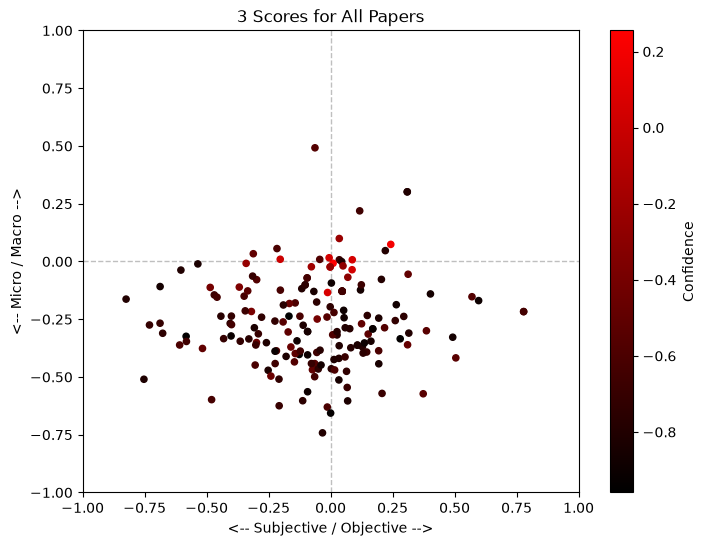

In [17]:
df_scores = pd.read_csv("scores.csv")
print(df_scores.head())

min_conf = df_scores["Confidence"].min()
max_conf = df_scores["Confidence"].max()


fig, ax = plt.subplots(figsize=(8,6))

cmap = LinearSegmentedColormap.from_list("black_red", ["black", "red"])

df_scores.plot.scatter(x="Focus", 
                       y="Magnitude", 
                       c="Confidence", 
                       cmap=cmap, #or "inferno"
                       vmin=min_conf,
                       vmax=max_conf,
                       sharex=False,
                       ax=ax)

plt.title("3 Scores for All Papers")
plt.xlabel("<-- Subjective / Objective -->")
plt.ylabel("<-- Micro / Macro -->")

plt.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.25, zorder=0)
plt.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.25, zorder=0)

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.show()

### Graphs Throughout the Decades

#### 5 Dataframes for 5 Decades

In [18]:
df_scores_80s = df_scores[(df_scores["Year"] >= 1980) & (df_scores["Year"] < 1990)].copy()
df_scores_90s = df_scores[(df_scores["Year"] >= 1990) & (df_scores["Year"] < 2000)].copy()
df_scores_00s = df_scores[(df_scores["Year"] >= 2000) & (df_scores["Year"] < 2010)].copy()
df_scores_10s = df_scores[(df_scores["Year"] >= 2010) & (df_scores["Year"] < 2020)].copy()
df_scores_20s = df_scores[(df_scores["Year"] >= 2020)].copy()
decades = [df_scores_80s,
           df_scores_90s,
           df_scores_00s,
           df_scores_10s,
           df_scores_20s]

print(f"Papers in the 80s: {len(df_scores_80s)}")
print(f"Papers in the 90s: {len(df_scores_90s)}")
print(f"Papers in the 00s: {len(df_scores_00s)}")
print(f"Papers in the 10s: {len(df_scores_10s)}")
print(f"Papers in the 20s: {len(df_scores_20s)}")
print(f"All together: {len(df_scores_80s) + len(df_scores_90s) + len(df_scores_00s) + len(df_scores_10s) + len(df_scores_20s)}")

Papers in the 80s: 20
Papers in the 90s: 16
Papers in the 00s: 18
Papers in the 10s: 56
Papers in the 20s: 64
All together: 174


#### Displaying the Decades

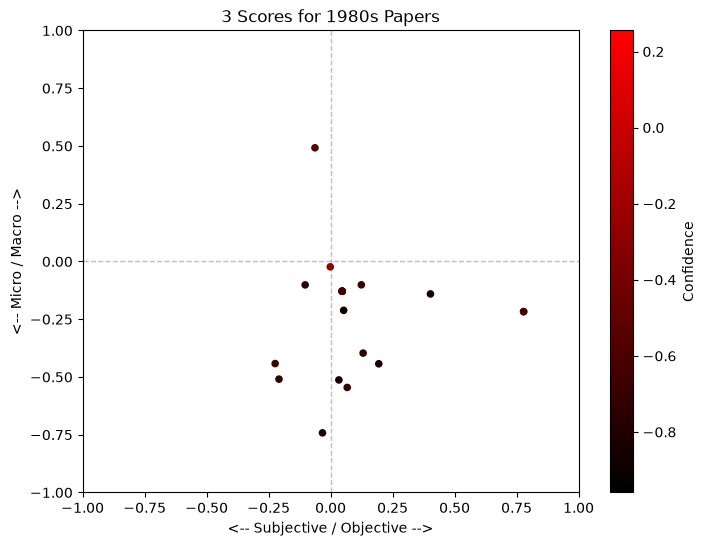

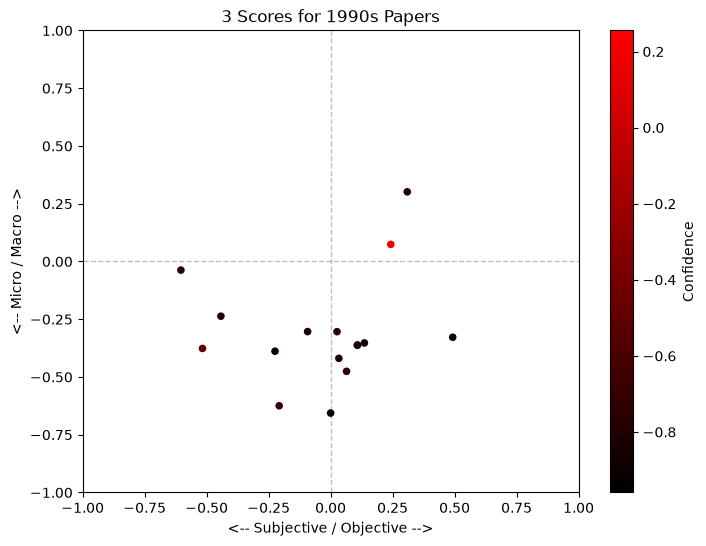

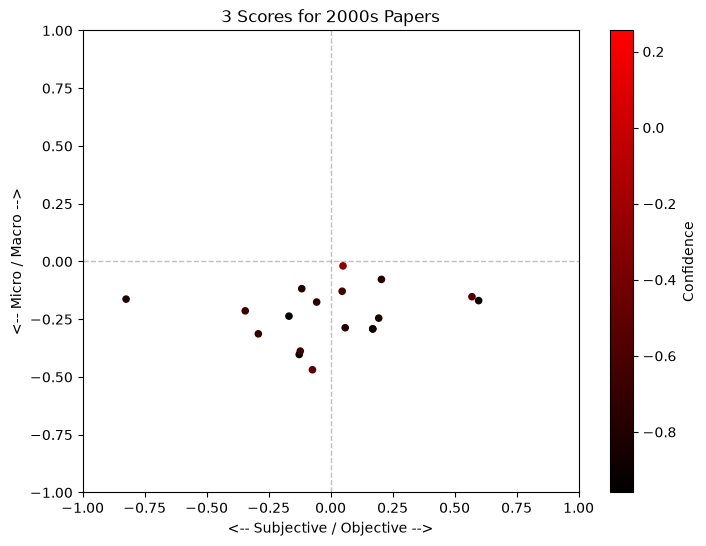

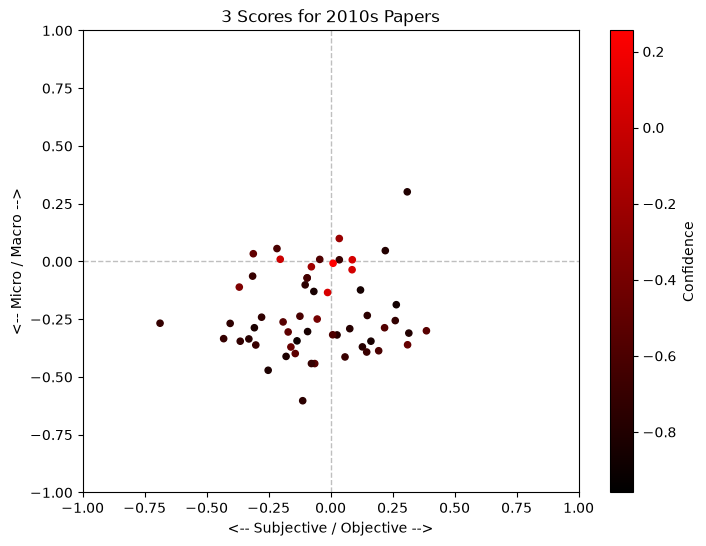

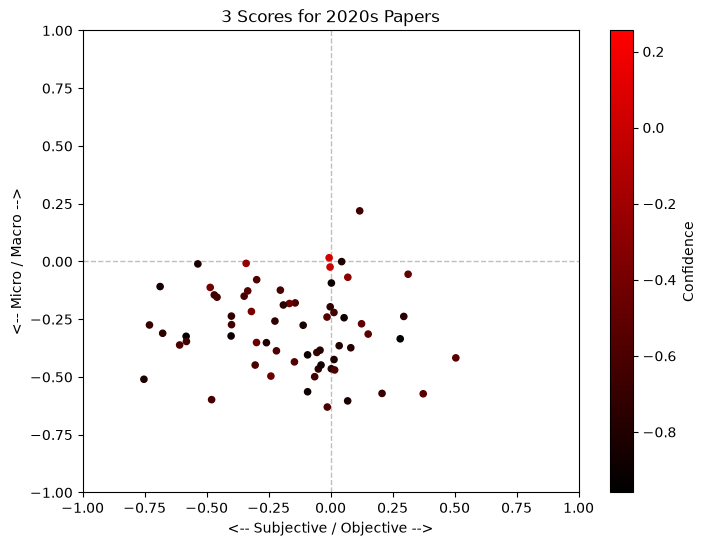

In [19]:
for i in range(len(decades)):
    fig, ax = plt.subplots(figsize=(8,6))

    decades[i].plot.scatter(x="Focus", 
                       y="Magnitude", 
                       c="Confidence", 
                       cmap=cmap,
                       vmin=min_conf,
                       vmax=max_conf,
                       sharex=False,
                       ax=ax)

    plt.title(f"3 Scores for {1980 + i * 10}s Papers")
    plt.xlabel("<-- Subjective / Objective -->")
    plt.ylabel("<-- Micro / Macro -->")

    plt.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.25, zorder=0)
    plt.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.25, zorder=0)

    plt.xlim(-1,1)
    plt.ylim(-1,1)

    plt.show()